# **Read Me** (for Daniel and Edward)

This is the work we have done with David and Moses last semester. Feel free to continue down the same notebook or start from a new one. You will need the `star_cat_func.py` library for some of the functions to work. The notebooks is organized as follows:
1. **Create a binary image for star extraction from the original All-Sky Imager image** (only one frame per video is enough; the camera remains still throughout the video). This star extraction is done using the `load_data_image` function with input parameters `ori_rotation` (the angle to rotate the image by to align it with true North up), `ori_img_center` (the pixel location of the center to rotate the image around), and `ori_brightness_threshold` (the pixel brightness threshold above which stars are detected, ranges from 0-255). Once the image is cleaned up, we create the `P` matrix containing the pixel coordinates of each star by finding the centroids of each star pixel cluster. This is done using the `get_star_centroids` function.
2. **Create a simulated sky image** using the observer's location and time of observation as inputs (based on the `star_catalog.csv`). We use the brightness parameter `Vmag_threshold` to filter out the stars that are too dim to be visible by the naked eye (and camera) from the catalog. Then we use the function `stars_to_polar_binary` with parameters `img_size` (pixel size of the simulated image, default=4000) and `point_size` (pixel size of each star, only relevant to visualize the image, default=1) to create the simulated image from the remaining stars.
3. **Distort the simulated image to best match the original image**. This is done using the `distort_image` function with parameters `t` (dilation from center, ranges 0-1), returning the matrix of distorted star pixel coordinates `Q`. For visualization, we can create a new distorted image using the `redraw_with_user_xy` function with `Q` as input.
4. **Calculate the distance matrix `D` to find the star pairs**. Once `D` is calculated, we match stars from `P` and `Q` based on proximity. Using the `max_dist` parameter, we can filter out the matches that are unreasonably far apart. _Note that some stars in `P` may get matched to two stars in `Q` and vice-versa; we still need to implement a filter for doublon matches!_
5. **Future work (your contribution!)**: We have used multiple parameters to optimize our fitting so far, including `ori_rotation`, `ori_img_center`, `ori_brightness_threshold` for processing of the original image, `Vmag_threshold` and `t` for the creation of the distorted simulated image, and `max_dist` for the filtering of unreasonable matches. In the example given in this notebook, the ground truth for `ori_rotation` and `ori_img_center` were used, and best guess estimates were used for `ori_brightness_threshold`, `Vmag_threshold`, `t`, and `max_dist`. The results are pretty good, but in a realistic scenario, we wouldn't know the truth values of `ori_rotation` and `ori_img_center`, and in order to make it fully automated, we would need the algorithm to make non-educated guesses for us. That's where ML comes in.

E.g.: The last part of the notebook presents a case where instead of choosing the truth value of `ori_rotation` as our first guess, we iterate over possible `ori_rotation` values from 0 to 90° and run the distance matching algorithm from there. By ensuring that we weigh the total distances by the number of stars matched for each value of `ori_rotation`, we find the correct truth value! But what if we don't know `ori_img_center` either? And what if we work with other images, would the same initial guesses work? That's for you to find out.

# **Library imports**

In [37]:
import cv2
import numpy as np
import star_cat_func as st
import matplotlib.pyplot as plt
from tqdm import tqdm
from importlib import reload
reload(st)

<module 'star_cat_func' from '/projectnb/semetergrp/nina/asi-starfield-calibration/star_cat_func.py'>

# **1. Create a binary image for star extraction from a single frame of the original All-Sky Imager (ASI) footage**

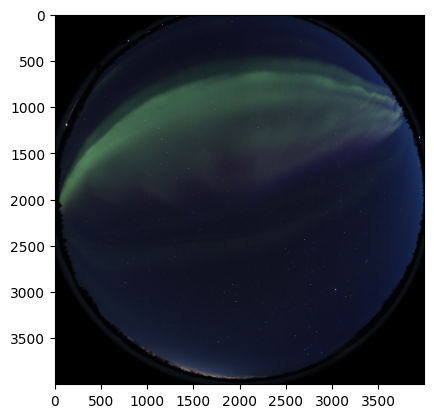

In [38]:
# Visualize the original image

ori_img_path = 'asi_frame.jpg'

ori_img = cv2.imread(ori_img_path, cv2.IMREAD_COLOR_RGB)

plt.imshow(ori_img)

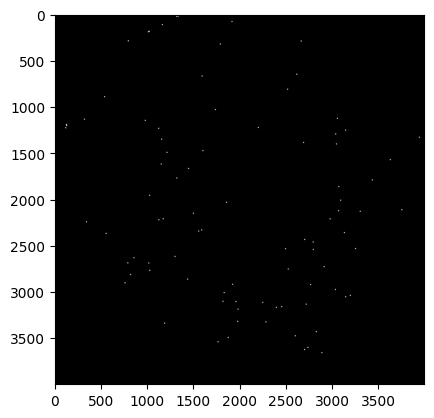

In [39]:
# Create the binary image

ori_bright_thresh = 50  # estimated guess

ori_img_cleaned, O, ori_img_binary = st.load_data_image(img_path=ori_img_path,
                                                        ori_bright_thresh=ori_bright_thresh,
                                                        point_size=10)

plt.imshow(ori_img_binary, cmap='gray')

# **2. Create simulated sky images**

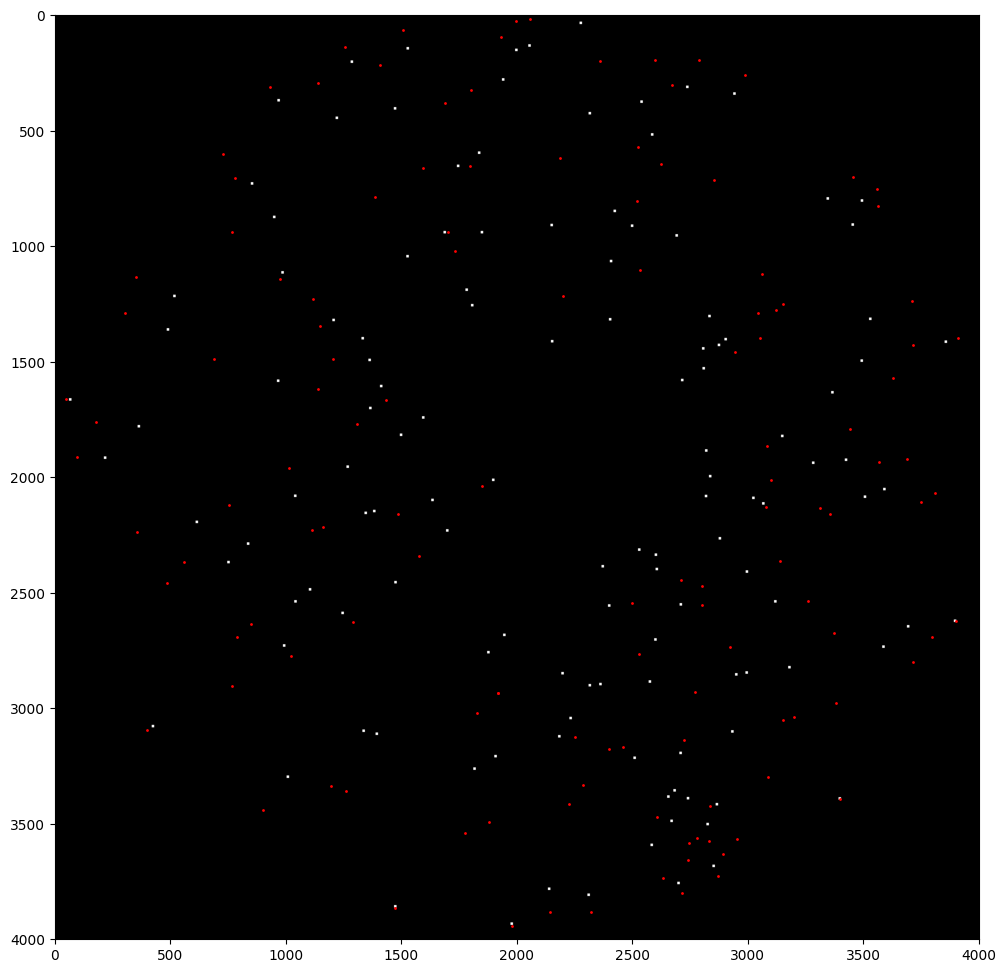

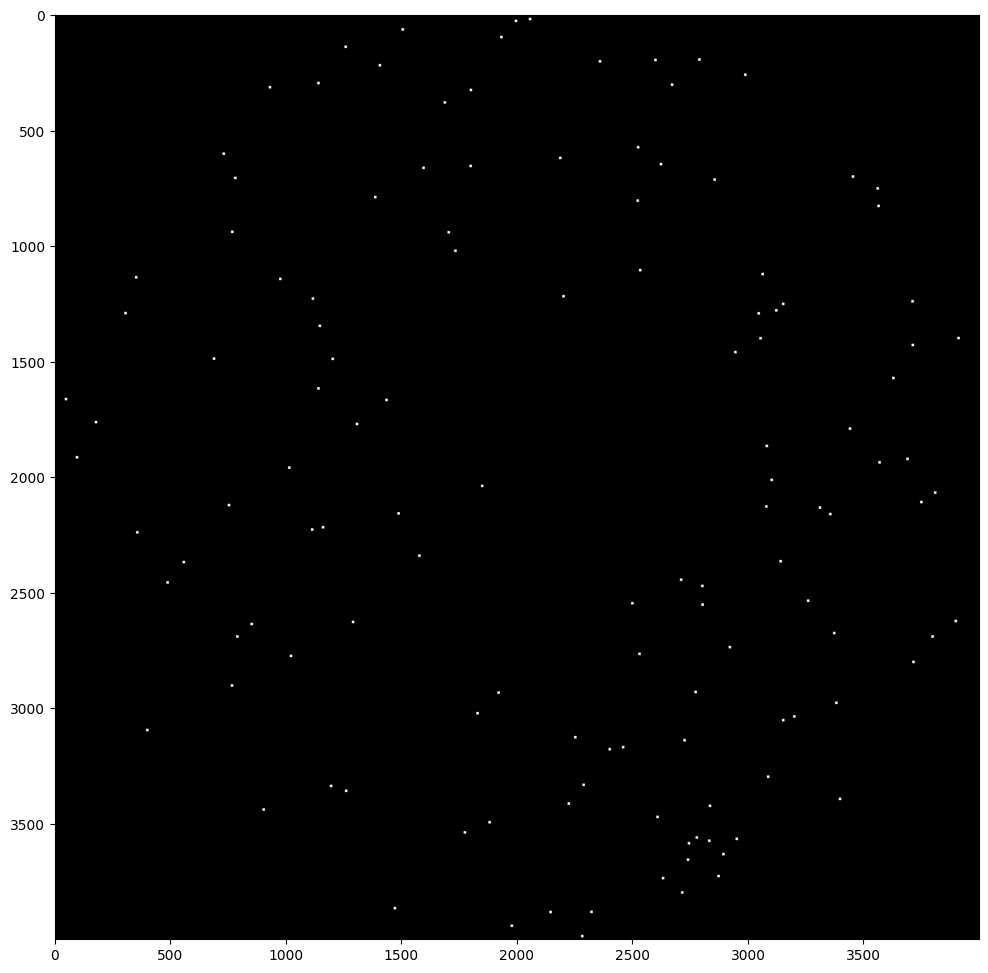

In [40]:
# Load star coordinates
camera_location = (65.0782920060381, -147.74736306279442, 161.57176208496094 + 9.314)  # (latitude N, longitude E, height above ellispoid (m))
observation_time = "2025-03-17 06:04:46"                                               # timestamp of the used ASI frame
star_cat_path = "star_catalog.csv"
Vmag_threshold = 3.5  # estimated guess for naked-eye visibility (see star catalog)

el, az = st.load_star_el_az(star_cat_path=star_cat_path,
                            Vmag_threshold=Vmag_threshold,
                            observation_time=observation_time,
                            camera_location=camera_location)

# Linear simulated image
ori_img_center = (2019, 1946)  # truth value
ori_rotation = 12.6            # truth value
ori_img_size = ori_img.shape[0]

sim_img_xy_el_az_linear = st.simulate_starfield(el=el,
                                        az=az,
                                        ori_img_size=ori_img_size,
                                        ori_rotation=-ori_rotation,
                                        ori_img_center=ori_img_center,
                                        t=0)

S_linear = sim_img_xy_el_az_linear[:2, :].T
S_linear_p = S_linear.astype(int)

sim_img_linear = st.create_img_from_xy(x=S_linear_p[:, 0],
                                y=S_linear_p[:, 1],
                                img_size=ori_img_size,
                                point_size=10)

# Distorted simulated image
t = 0.7  # educated guess

sim_img_xy_el_az= st.simulate_starfield(el=el,
                                        az=az,
                                        ori_img_size=ori_img_size,
                                        ori_rotation=-ori_rotation,
                                        ori_img_center=ori_img_center,
                                        t=t)

S = sim_img_xy_el_az[:2, :].T
S_p = S.astype(int)

sim_img = st.create_img_from_xy(x=S_p[:, 0],
                                y=S_p[:, 1],
                                img_size=ori_img_size,
                                point_size=10)

# Figure of linear (white) vs distorted (red)
plt.figure(figsize=(12, 12))
plt.imshow(sim_img_linear, cmap='gray')
plt.scatter(S[:, 0], S[:, 1], s=1, c='red')
plt.xlim(0, sim_img_linear.shape[0])
plt.ylim(sim_img_linear.shape[1], 0)

# Figure of distorted 
plt.figure(figsize=(12, 12))
plt.imshow(sim_img, cmap='gray')

# **4. Calculate the distance matrix to find star pairs$$ D = \sqrt(\mathbf{a}.\mathbf{1}_n^\top + \mathbf{1}_m.\mathbf{b}^\top - 2OS^\top)$$**

In [41]:
# Distance matrix computation

m = len(O)
n = len(S)

onesM = np.ones(shape=(m, 1))
onesN = np.ones(shape=(n, 1))

a = np.diag(np.dot(O, O.T))
b = np.diag(np.dot(S, S.T))

a = a[:, None]
b = b[:, None]

D = np.sqrt(np.matmul(a, onesN.T) + np.matmul(onesM, b.T) - 2 * np.matmul(O, S.T))

print(D.shape)

(89, 130)


In [42]:
# Find matching pairs (minimizing distance)

matches = []
dist = 0
for i in range(D.shape[0]):       # for each star in O (i)
    j = np.argmin(D[i])           # find closest star in S (j)
    dist_ij = D[i, j]             # save the distance between i and j
    matches.append((i, j, dist_ij))  # save matching pair
matches = np.array(matches)
total_dist = np.sum(matches[:, 2])
print(matches.shape, total_dist)

# Optionally, filter out matches with unreasonable distances
max_dist = 100                      # adjust depending on scale
filtered_matches = matches[matches[:, 2] < max_dist]
total_dist_filt = np.sum(filtered_matches[:, 2])
print(filtered_matches.shape, total_dist_filt)

(89, 3) 4449.639993020806
(71, 3) 1167.4035815895415


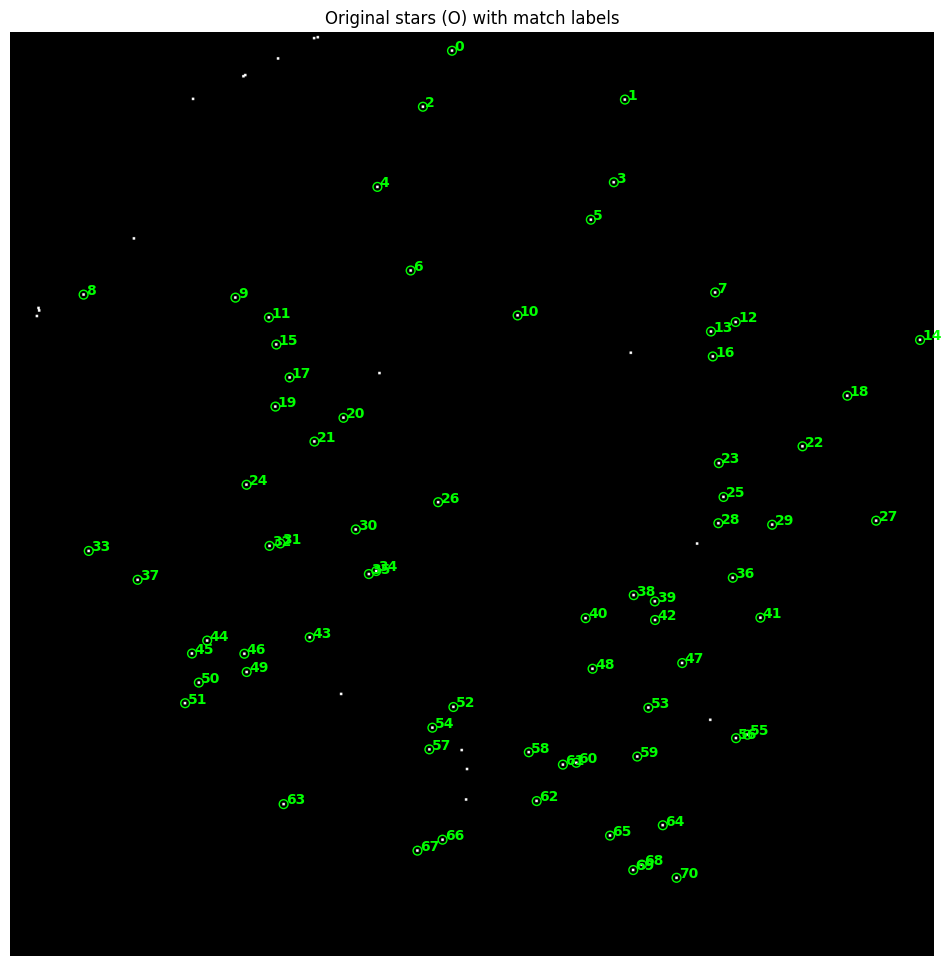

In [43]:
# Check matched pairs in original image

plt.figure(figsize=(12, 12))
plt.imshow(ori_img_binary, cmap='gray')
plt.title("Original stars (O) with match labels")
plt.axis('off')

for idx, (i, j, dist_ij) in enumerate(filtered_matches):
    x, y = O[int(i)]
    plt.scatter(x, y, s=40, edgecolors='lime', facecolors='none')
    plt.text(x + 10, y, f"{idx}", color='lime', fontsize=10, fontweight='bold')

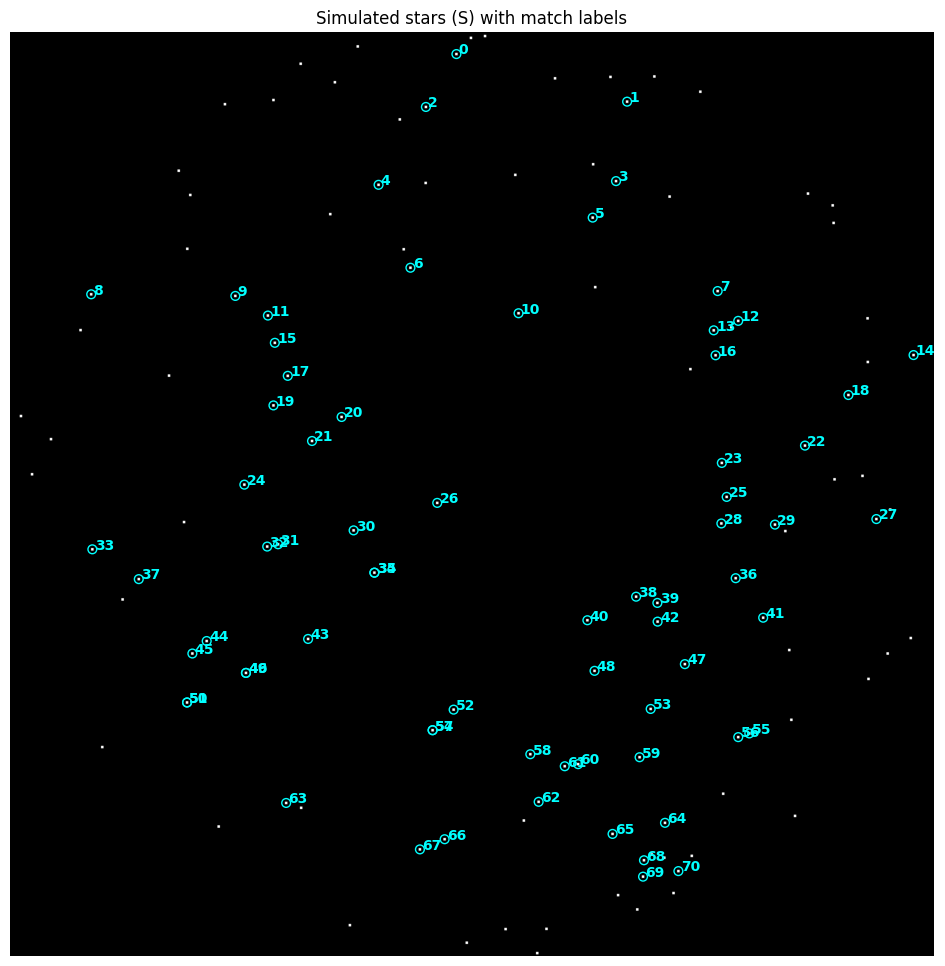

In [44]:
# Check matched pairs in the simulated image

plt.figure(figsize=(12, 12))
plt.imshow(sim_img, cmap='gray')
plt.title("Simulated stars (S) with match labels")
plt.axis('off')

for idx, (i, j, dist_ij) in enumerate(filtered_matches):
    x, y = S[int(j)]
    plt.scatter(x, y, s=40, edgecolors='cyan', facecolors='none')
    plt.text(x + 10, y, f"{idx}", color='cyan', fontsize=10, fontweight='bold')

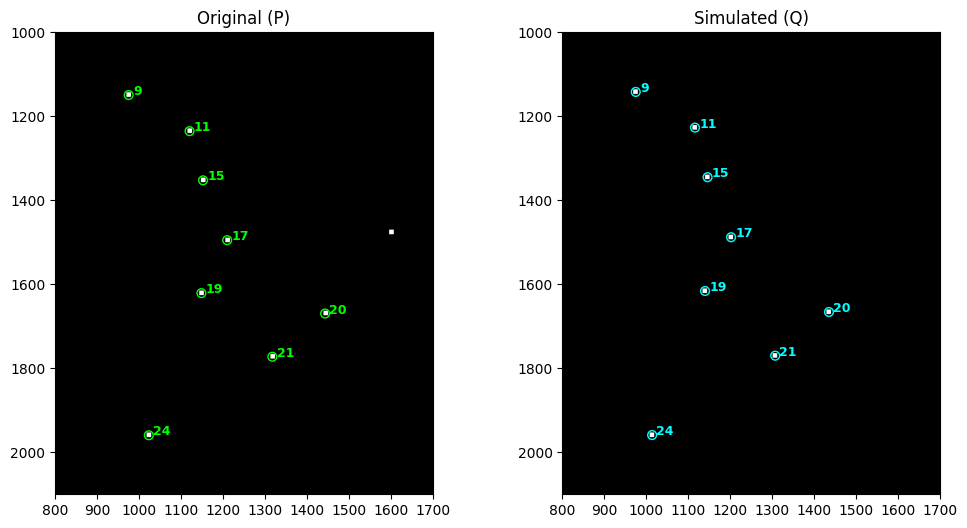

1167.4035815895415


In [45]:
# Check the Big Dipper again to see if the function works correctly

fig, axes = plt.subplots(1, 2, figsize=(12,6))
xmin, xmax = 800, 1700
ymin, ymax = 1000, 2100

# Left: original image
axes[0].imshow(ori_img_binary, cmap='gray')
axes[0].set_title("Original (P)")
axes[0].set_xlim(xmin, xmax)
axes[0].set_ylim(ymax, ymin)
for idx, (i, j, dist_ij) in enumerate(filtered_matches):
    x, y = O[int(i)]
    if (x >= xmin) and (x <= xmax) and (y >= ymin) and (y <= ymax):
        axes[0].scatter(x, y, s=40, edgecolors='lime', facecolors='none')
        axes[0].text(x + 10, y, f"{idx}", color='lime', fontsize=9, fontweight='bold')

# Right: simulated image
axes[1].imshow(sim_img, cmap='gray')
axes[1].set_title("Simulated (Q)")
axes[1].set_xlim(xmin, xmax)
axes[1].set_ylim(ymax, ymin)
for idx, (i, j, dist_ij) in enumerate(filtered_matches):
    x, y = S[int(j)]
    if (x >= xmin) and (x <= xmax) and (y >= ymin) and (y <= ymax):
        axes[1].scatter(x, y, s=40, edgecolors='cyan', facecolors='none')
        axes[1].text(x + 10, y, f"{idx}", color='cyan', fontsize=9, fontweight='bold')

plt.show()

print(np.sum(filtered_matches[:, 2]))

# **Make it a function**


In [46]:
from importlib import reload
reload(st)

def match_stars(ori_img_path, star_cat_path, observation_time, camera_location, ori_rotation, ori_img_center, ori_bright_thresh, t, Vmag_threshold, max_dist):

  # 1. Load original image

  ori_img_cleaned, O, ori_img_binary = st.load_data_image(img_path=ori_img_path,
                                                          ori_bright_thresh=ori_bright_thresh,
                                                          min_area=3,
                                                          max_area=200,
                                                          point_size=10)
  ori_img_size = ori_img_binary.shape[0]

  # 2. Create (distorted) simulated image

  el, az = st.load_star_el_az(star_cat_path=star_cat_path,
                              Vmag_threshold=Vmag_threshold,
                              observation_time=observation_time,
                              camera_location=camera_location)

  sim_img_xy_el_az = st.simulate_starfield(el=el,
                                           az=az,
                                           ori_img_size=ori_img_size,
                                           ori_rotation=-ori_rotation,
                                           ori_img_center=ori_img_center,
                                           t=t)

  S = sim_img_xy_el_az[:2, :].T
  S_p = S.astype(int)

  sim_img = st.create_img_from_xy(x=S_p[:, 0],
                                  y=S_p[:, 1],
                                  img_size=ori_img_size,
                                  point_size=10)

  # 3. Calculate distance matrix

  m = len(O)
  n = len(S)

  onesM = np.ones(shape=(m, 1))
  onesN = np.ones(shape=(n, 1))

  a = np.diag(np.dot(O, O.T))
  b = np.diag(np.dot(S, S.T))

  a = a[:, None]
  b = b[:, None]

  D = np.sqrt(np.matmul(a, onesN.T) + np.matmul(onesM, b.T) - 2 * np.matmul(O, S.T))

  # 4. Match pairs

  matches = []
  dist = 0
  for i in range(D.shape[0]):
      j = np.argmin(D[i])
      dist_ij = D[i, j]
      matches.append((i, j, dist_ij))
  matches = np.array(matches)

  if max_dist is not None:
    filtered_matches = matches[matches[:, 2] < max_dist]
  else:
    filtered_matches = None

  return ori_img_binary, sim_img, matches, filtered_matches, D, O, S

In [47]:
ori_img_path = 'asi_frame.jpg'
star_cat_path = 'star_catalog.csv'
observation_time = '2025-03-17 06:04:46'
camera_location = (65.0782920060381, -147.74736306279442, 161.57176208496094 + 9.314)
ori_rotation = 12.6
ori_bright_thresh = 50
ori_img_center = (2019, 1946)
t = 0.7
Vmag_threshold = 3.5
max_dist = 100

ori_img_binary, sim_img, matches, filtered_matches, D, O, S = match_stars(ori_img_path=ori_img_path,
                                                                          star_cat_path=star_cat_path,
                                                                          observation_time=observation_time,
                                                                          camera_location=camera_location,
                                                                          ori_rotation=ori_rotation,
                                                                          ori_bright_thresh=ori_bright_thresh,
                                                                          ori_img_center=ori_img_center, 
                                                                          t=t, 
                                                                          Vmag_threshold=Vmag_threshold,
                                                                          max_dist=max_dist)


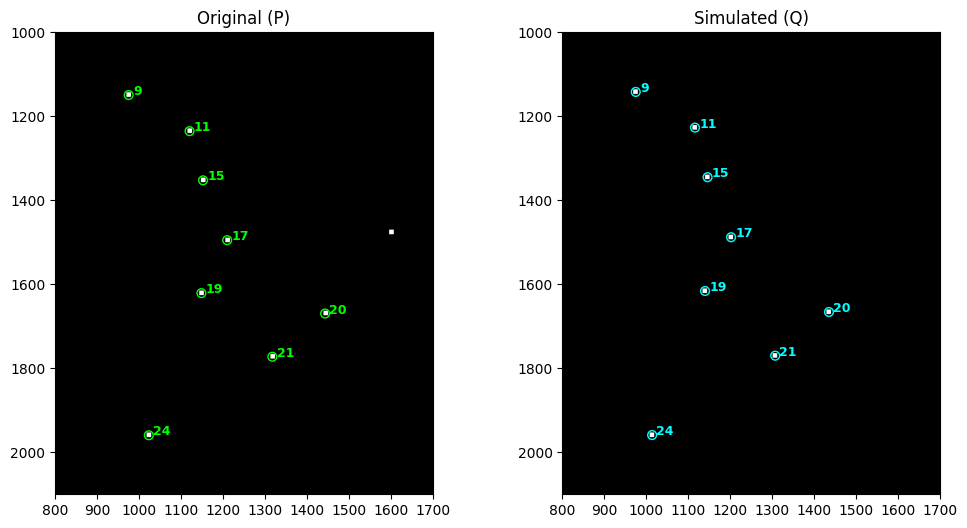

1167.4035815895415


In [48]:
# Check the Big Dipper again to see if the function works correctly

fig, axes = plt.subplots(1, 2, figsize=(12,6))
xmin, xmax = 800, 1700
ymin, ymax = 1000, 2100

# Left: original image
axes[0].imshow(ori_img_binary, cmap='gray')
axes[0].set_title("Original (P)")
axes[0].set_xlim(xmin, xmax)
axes[0].set_ylim(ymax, ymin)
for idx, (i, j, dist_ij) in enumerate(filtered_matches):
    x, y = O[int(i)]
    if (x >= xmin) and (x <= xmax) and (y >= ymin) and (y <= ymax):
        axes[0].scatter(x, y, s=40, edgecolors='lime', facecolors='none')
        axes[0].text(x + 10, y, f"{idx}", color='lime', fontsize=9, fontweight='bold')

# Right: simulated image
axes[1].imshow(sim_img, cmap='gray')
axes[1].set_title("Simulated (Q)")
axes[1].set_xlim(xmin, xmax)
axes[1].set_ylim(ymax, ymin)
for idx, (i, j, dist_ij) in enumerate(filtered_matches):
    x, y = S[int(j)]
    if (x >= xmin) and (x <= xmax) and (y >= ymin) and (y <= ymax):
        axes[1].scatter(x, y, s=40, edgecolors='cyan', facecolors='none')
        axes[1].text(x + 10, y, f"{idx}", color='cyan', fontsize=9, fontweight='bold')

plt.show()

print(np.sum(filtered_matches[:, 2]))

# 5. Now optimize!
...over `ori_rotation`, `ori_img_center`, `t`, `Vmag_threshold`, `ori_bright_thresh`, `max_dist`, etc

In [49]:
# Example, which ori_rotation gives the lowest total filtered distance?

ori_rotation_range = np.arange(0, 90)

total_distances = np.zeros(ori_rotation_range.size) * np.nan
total_num_stars = np.zeros(ori_rotation_range.size) * np.nan
for i in tqdm(range(ori_rotation_range.size)):
    _, _, _, filtered_matches, _, _, _ = match_stars(ori_img_path=ori_img_path,
                                                     star_cat_path=star_cat_path,
                                                     observation_time=observation_time,
                                                     camera_location=camera_location,
                                                     ori_rotation=ori_rotation_range[i],
                                                     ori_bright_thresh=ori_bright_thresh,
                                                     ori_img_center=ori_img_center, 
                                                     t=t, 
                                                     Vmag_threshold=Vmag_threshold,
                                                     max_dist=max_dist)
    total_distances[i] = np.sum(filtered_matches[:, 2])
    total_num_stars[i] = np.shape(filtered_matches)[0]

100%|██████████| 90/90 [00:15<00:00,  5.91it/s]


13


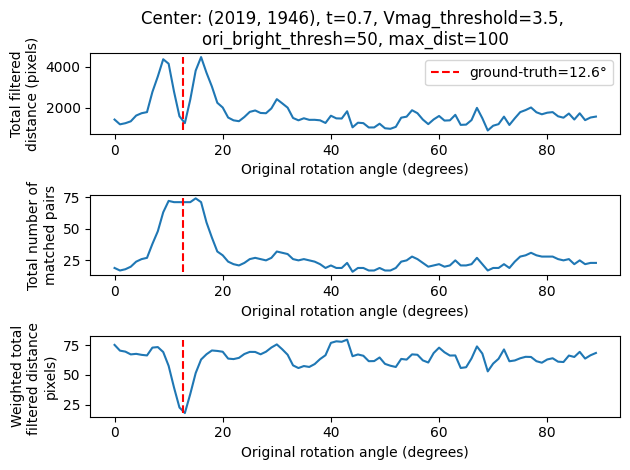

In [50]:
plt.subplot(3, 1, 1)
plt.plot(ori_rotation_range, total_distances)
plt.title(f'Center: {ori_img_center[0], ori_img_center[1]}, t={t}, Vmag_threshold={Vmag_threshold}, \nori_bright_thresh={ori_bright_thresh}, max_dist={max_dist}')
plt.xlabel('Original rotation angle (degrees)')
plt.ylabel('Total filtered\ndistance (pixels)')
plt.vlines(12.6, total_distances.min(), total_distances.max(), color='r', ls='--', label='ground-truth=12.6°')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(ori_rotation_range, total_num_stars)
plt.xlabel('Original rotation angle (degrees)')
plt.ylabel('Total number of\nmatched pairs')
plt.vlines(12.6, total_num_stars.min(), total_num_stars.max(), color='r', ls='--')

plt.subplot(3, 1, 3)
weighted_distances = total_distances / total_num_stars
plt.plot(ori_rotation_range, weighted_distances)
plt.xlabel('Original rotation angle (degrees)')
plt.ylabel('Weighted total\nfiltered distance \npixels)')
plt.vlines(12.6, weighted_distances.min(), weighted_distances.max(), color='r', ls='--')

plt.tight_layout()

print(ori_rotation_range[np.argmin(weighted_distances)])

In [51]:
# ...and what if we don't enforce a maximum distance for paired matches?

ori_rotation_range = np.arange(0, 90)
max_dist = 1e7

total_distances = np.zeros(ori_rotation_range.size) * np.nan
total_num_stars = np.zeros(ori_rotation_range.size) * np.nan
for i in tqdm(range(ori_rotation_range.size)):
    _, _, matches, _, _, _, _ = match_stars(ori_img_path=ori_img_path,
                                            star_cat_path=star_cat_path,
                                            observation_time=observation_time,
                                            camera_location=camera_location,
                                            ori_rotation=ori_rotation_range[i],
                                            ori_bright_thresh=ori_bright_thresh,
                                            ori_img_center=ori_img_center, 
                                            t=t, 
                                            Vmag_threshold=Vmag_threshold,
                                            max_dist=max_dist)
    total_distances[i] = np.sum(matches[:, 2])
    total_num_stars[i] = np.shape(matches)[0]

100%|██████████| 90/90 [00:14<00:00,  6.20it/s]


13


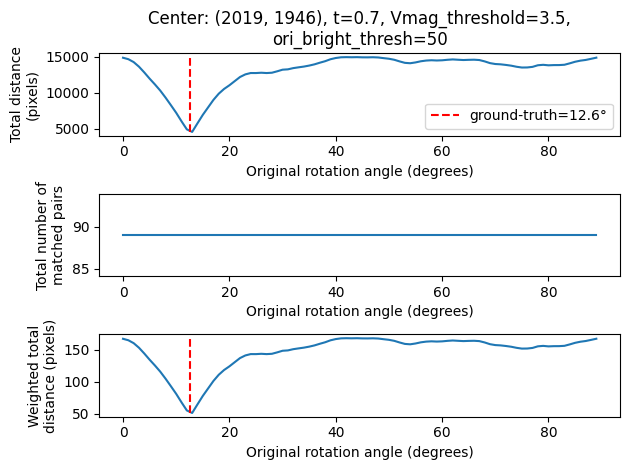

In [52]:
plt.subplot(3, 1, 1)
plt.plot(ori_rotation_range, total_distances)
plt.title(f'Center: {ori_img_center[0], ori_img_center[1]}, t={t}, Vmag_threshold={Vmag_threshold},\nori_bright_thresh={ori_bright_thresh}')
plt.xlabel('Original rotation angle (degrees)')
plt.ylabel('Total distance\n(pixels)')
plt.vlines(12.6, total_distances.min(), total_distances.max(), color='r', ls='--', label='ground-truth=12.6°')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(ori_rotation_range, total_num_stars)
plt.xlabel('Original rotation angle (degrees)')
plt.ylabel('Total number of\nmatched pairs')
plt.vlines(12.6, total_num_stars.min(), total_num_stars.max(), color='r', ls='--')

plt.subplot(3, 1, 3)
weighted_distances = total_distances / total_num_stars
plt.plot(ori_rotation_range, weighted_distances)
plt.xlabel('Original rotation angle (degrees)')
plt.ylabel('Weighted total\ndistance (pixels)')
plt.vlines(12.6, weighted_distances.min(), weighted_distances.max(), color='r', ls='--')

plt.tight_layout()

print(ori_rotation_range[np.argmin(weighted_distances)])